6.1

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
shape is (530, 530)
dtype is >i2
mean is 4795.924268422927
min ia 1507
max is 15752
std is 1848.2526085366376
median is 4102.0
mode is 3551 and count is 876


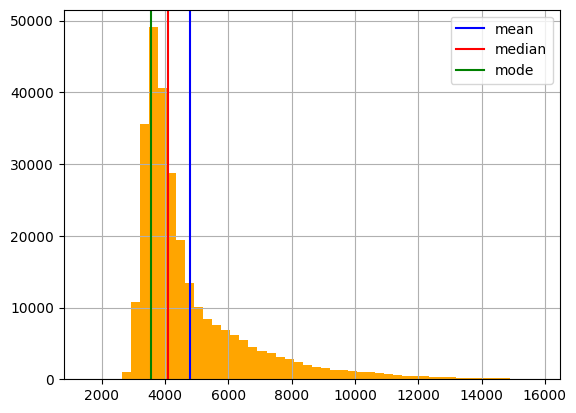

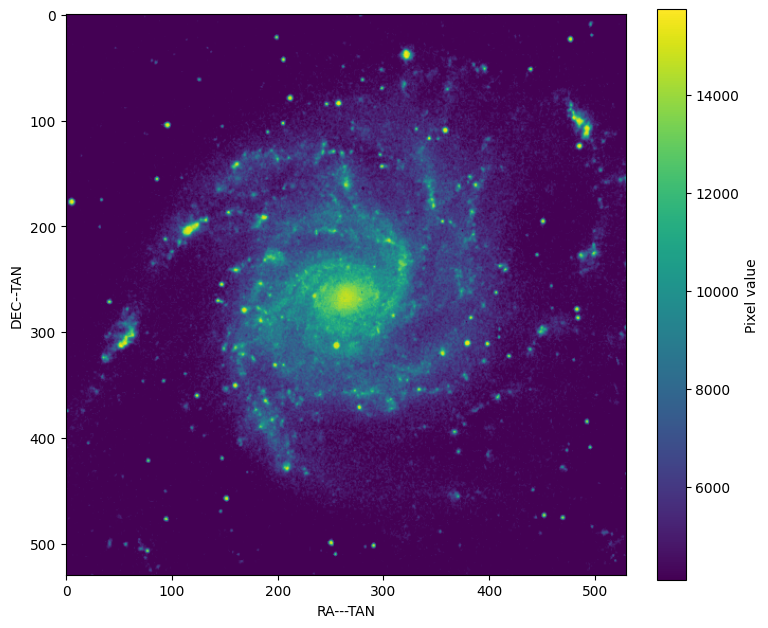

new FITS file created with BUNIT='Counts'


 [astropy.io.fits.verify]


In [14]:
from astropy.io import fits
import numpy as np
hdul = fits.open("m101.fits")
hdul.info()
#2 HDU
#data in primary index 0
#number type is int16
header = hdul[0].header
for key in header[:5]:
    print(f"{key:18s}= {header[key]}")
#BITPIX=16, matches data type
dat = hdul[0].data
print("shape is", dat.shape)
#matches with info
#also matches NAXIS, 2 and two dimensions
print("dtype is", dat.dtype)
#The dtype >i2 refers to a 16-bit integer. Dtype is object that descripes how bytes are interpreted as data
dat_flat = dat.flatten()
print("mean is", np.mean(dat_flat))
print("min ia", np.min(dat_flat))
print("max is", np.max(dat_flat))
print("std is", np.std(dat_flat))
print("median is", np.median(dat_flat))

from scipy import stats
mode, count = stats.mode(dat_flat)

print(f"mode is {mode} and count is {count}")


#histogram
import matplotlib.pyplot as plt
fig = plt.figure()
frame = fig.add_subplot(1,1,1)
frame.hist(dat.flat, bins=50, color="orange")
frame.grid()
frame.axvline(np.mean(dat_flat), color = 'blue', label = 'mean')
frame.axvline(np.median(dat_flat), color = 'red', label = 'median')
frame.axvline(mode, color = 'green', label = 'mode')
plt.legend()
plt.show()

#convert data again
fig, frame = plt.subplots(figsize=(8,8))
data_new = np.asarray(dat)
median_new = np.median(data_new)

image = frame.imshow(data_new, vmin = median_new)
frame.set_xlabel(header["CTYPE1"])
frame.set_ylabel(header["CTYPE2"])
cbar = fig.colorbar(image, fraction=0.046)
cbar.set_label("Pixel value")
plt.show()

#add new keyword
copy = hdul[0].header.copy()
copy['BUNIT'] = 'Counts'

hdulout = fits.PrimaryHDU(data_new)
hdulout.header = copy
hdulout.writeto('m101_new.fits', overwrite=True, output_verify='ignore')
hdul.close()
print("new FITS file created with BUNIT='Counts'")


6.3

rms is:  60.79673099764493
mean is:  3422.8825
std is:  260.1300322795313
3696.2425
std measures fluctuations around mean and RMS includes the mean, so when mean is high, RMS would be quite higher than std 
std works better for background noise, since it avoids brighter parts that RMS would include 


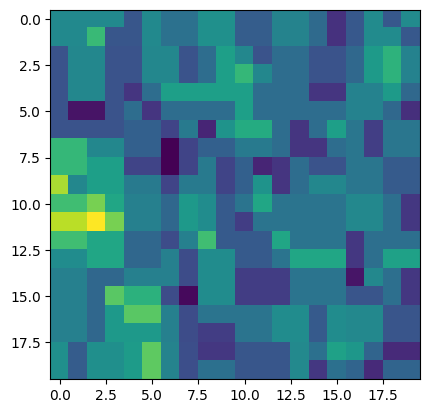

In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
hdul = fits.open("m101.fits")
data = hdul[0].data
plt.imshow(data)

#define slice with only background noise
x1= 0
x2= 20
y1= 0
y2= 20
area = data[y1:y2, x1:x2]
plt.imshow(area)


#RMS formula
rms = np.sqrt(np.mean(area**2))

#print statistics
print('rms is: ', rms)
print('mean is: ', np.mean(area))
print('std is: ', np.std(area))
print(np.mean(area**2))


print(f'std measures fluctuations around mean and RMS includes the mean, so when mean is high, RMS would be quite higher than std ')
print(f'std works better for background noise, since it avoids brighter parts that RMS would include ')


6.5

In [3]:
from astropy.io import fits
import numpy as np
hdul0 = fits.open("noisemap0.fits")
hdul1 = fits.open("noisemap1.fits")
hdul2 = fits.open("noisemap2.fits")

data0 = hdul0[0].data
data1 = hdul1[0].data
data2 = hdul2[0].data


#standard deviation
std0 = np.std(data0)
std1 = np.std(data1)
std2 = np.std(data2)


print("std 1 is: ",std0)
print("std 2 is: ",std1)
print("std 3 is: ",std2)

#stack
stack = np.stack([data0,data1,data2], axis=0)

#mean
mean_img = np.mean(stack, axis=0)

#standard deviation image
std_img = np.std(mean_img)
print("std of image is:", std_img)

#sigma
N = 3
sigma = (1/N)*np.sqrt(std0**2 + std1**2 + std2**2)
print("sigma is: ", sigma)

std 1 is:  9.98401556679484
std 2 is:  10.003955116338458
std 3 is:  9.995349488722516
std of image is: 5.773191380233297
sigma is:  5.770294583366139


6.6

In [4]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data  
colnames = hdul[1].columns.names 
print("fits file is hdul[0] and is numpy array (2D/3D). fits table is hdul[1] and structured array(rows and columns)")

table = Table(data)

#dataflag
starflag = table['STARFLAG']
aspcapflag = table['ASPCAPFLAG']
snr = table['SNR']
parallax = table['GAIAEDR3_PARALLAX']
parallax_err = table['GAIAEDR3_PARALLAX_ERROR']
gmag = table['GAIAEDR3_PHOT_G_MEAN_MAG']
bpmag = table['GAIAEDR3_PHOT_BP_MEAN_MAG']
rpmag = table['GAIAEDR3_PHOT_RP_MEAN_MAG']

#condition
mask = (
    (starflag == 0) &
    (aspcapflag == 0) &
    (snr > 10) &
    (parallax / parallax_err > 5) &
    (~np.isnan(gmag)) &
    (~np.isnan(bpmag)) &
    (~np.isnan(rpmag))
)

DATAFLAG = np.where(mask, 1, 0)

#add column
table['DATAFLAG'] = DATAFLAG

#absolute magnitude
abs_mag = np.full(len(table), -1.0)

valid = DATAFLAG == 1

abs_mag[valid] = gmag[valid] + 5 * np.log10(parallax[valid]/1000) + 5

#add column
table['abs_mag'] = abs_mag

#save new table
table.write('APOGEE_update.fits', overwrite = True)

#show
print(table)

fits file is hdul[0] and is numpy array (2D/3D). fits table is hdul[1] and structured array(rows and columns)
GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG      abs_mag      
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1 2.7881622314453125
      -0.02394128               0.0450072 ...        0               -1.0
        1.3863556               0.0175672 ...        1 2.9852724075317383
              ...                     ... ...      ...                ...
         4.132398                0.015343 ...        0               -1.0
      0.057267956               0.0597211 ...        0               -1.0
  

6.7

DataFrame loaded:    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
0   17418273  235.15720  0.005150  10.02086   0.004458        1779496.20   
1   17418274  235.26166  0.005151  10.02583   0.004461        1558733.60   
2   17418275  235.56832  0.005140  10.05378   0.004458         920389.44   
3   17418276  234.73462  0.005180  10.14044   0.004484         807482.50   
4   17418277  235.70156  0.005124  10.14876   0.004453        1122357.80   

   phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
0              240.864320        10.062657         1112220.10   
1              210.915800        10.206471          937470.70   
2              124.408295        10.778471          553550.70   
3              109.289300        10.920568          370091.66   
4              151.516890        10.563072          691627.70   

   phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
0                713.87630         10.235924          858547.75   


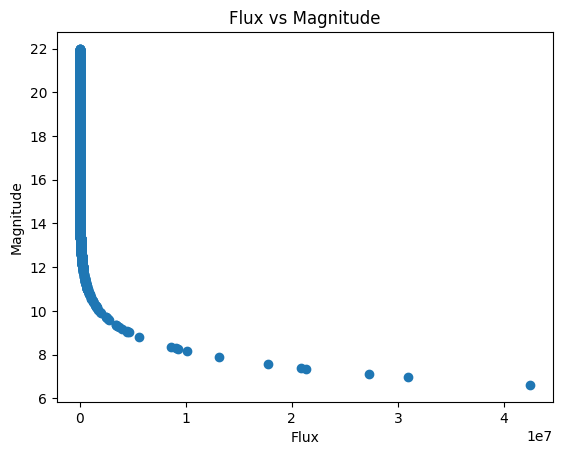

Estimated m0 is  0        25.688400
1        25.688400
2        25.688400
3        25.688400
4        25.688400
           ...    
32195    25.688400
32196    25.688401
32197    25.688400
32198    25.688401
32199    25.688401
Length: 32200, dtype: float64
Average m0 is  25.68840037029544


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#load file
file = pd.read_csv('gaiaTestData.csv')

print("DataFrame loaded:", file.head())

#maximum flux
max_flux = file['phot_g_mean_flux'].max()
max_row = file[file['phot_g_mean_flux'] == max_flux]
print()
print("maximum flux is: ", max_flux)
print("row with maximum flux: ", max_row)

#sort
file_sort = file.sort_values(by='phot_g_mean_flux')

#OOP
fig, frame = plt.subplots()
frame.scatter(file_sort['phot_g_mean_flux'], file_sort['phot_g_mean_mag'])
frame.set_xlabel('Flux')
frame.set_ylabel('Magnitude')
frame.set_title('Flux vs Magnitude')
plt.show()

mg = file['phot_g_mean_mag']
Fg = file['phot_g_mean_flux']
m0 = mg + 2.5*np.log10(Fg)

#average m0
avg = np.mean(m0)

#print
print("Estimated m0 is ", m0)
print("Average m0 is ", avg)

6.10

In [12]:
from astroquery.gaia import Gaia
import pandas as pd

query = """
SELECT TOP 50
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
"""

#send the query to archive and get results
job = Gaia.launch_job(query)
results = job.get_results()

#change to pandas
file = results.to_pandas()

print(file.head())

results.write("astroquery_gaia.fits", format="fits", overwrite=True)

       SOURCE_ID         ra       dec  parallax  parallax_error  \
0  5291399870976  44.920804  0.146074  0.379842        0.065169   
1  5394479088256  44.969992  0.163584  1.803277        0.105605   
2  5841155589888  44.840191  0.152562  2.642520        0.243267   
3  6528350458496  44.907032  0.206011  1.508512        0.097602   
4  9281425163264  45.165009  0.200053  3.800303        0.015949   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  
0        16.801189         17.172367         16.276566  
1        17.825970         19.044901         16.763569  
2        18.875731         20.593546         17.700752  
3        17.566711         18.737415         16.489899  
4        10.642890         10.946025         10.176743  


6.14

In [5]:
class Fibonacci:
  
    def __init__(self, n, m):
        self.n = n
        self.m = m
        
    
    def n_term(self):   #define first method of computing nth term of sequence
        n = self.n
        if n<0:
            raise ValueError
        elif n==0:
            return 0
        elif n==1:
            return 1
        
        a=0
        b=1  #initializing first two fibonacci numbers
        for i in range(2,n+1):
            a, b = b, a+b
        return b
    
    def divide_n_term(self):   #define second method of numbers less than n divisible by m
     
        if self.m==0:
            raise ValueError
        fib_n = self.n_term()
        
        result = []
        a=0
        b=1
        
        while a<fib_n:
            if a%self.m==0:
                result.append(a)
            a, b = b, a+b
        return result


#test
n = int(input("Enter the value n: "))
m = int(input("Enter the value m: "))

fib = Fibonacci(n, m)
    
#calling methods and printing results
nth_fib = fib.n_term()
print(f"The {n}th Fibonacci number is: {nth_fib}")
        

divisible_fibs = fib.divide_n_term()
print(f"Fibonacci numbers less than the {n}th term and divisible by {m}: {divisible_fibs}")
    
  




Enter the value n: 100
Enter the value m: 7
The 100th Fibonacci number is: 354224848179261915075
Fibonacci numbers less than the 100th term and divisible by 7: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
